In [1]:
#%pip install pandas==2.2.3
#%pip install git+https://github.com/pydata/pandas-datareader.git
#%pip install yfinance numpy matplotlib

In [2]:
import pandas as pd #Importamos pandas para el manejo de dataframes y series temporales
import numpy as np #Importamos numpy para operaciones numéricas y manejo de arrays
from sklearn.ensemble import GradientBoostingRegressor #Importamos el modelo de regresión Gradient Boosting de scikit-learn para realizar predicciones
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit #Importamos GridSearchCV para la búsqueda de hiperparámetros y TimeSeriesSplit para la validación cruzada específica para series temporales
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score #Importamos métricas de evaluación para medir el rendimiento del modelo, como el error absoluto medio (MAE) y el error cuadrático medio (MSE)
import joblib #Importamos joblib para guardar y cargar modelos de manera eficiente
import matplotlib.pyplot as plt #Importamos matplotlib para la visualización de datos y resultados

In [3]:
df = pd.read_csv('../../dataset_completo.csv')
df.head()

df.drop(columns=['Date'], inplace=True) #Eliminamos la columna 'Date' ya que no es una característica numérica y no aporta información relevante para el modelo. Además, eliminamos la columna 'target' ya que es la variable que queremos predecir.

In [4]:
X = df.drop(columns=['target']) #Separamos las características (X) de la variable objetivo (Y) para preparar los datos para el entrenamiento del modelo de machine learning.
Y = df['target']

In [5]:
def division_conjuntos(dataframe, tr_size=0.8, vl_size=0.1, ts_size=0.1 ):
    '''Función para dividir un dataframe en conjuntos de entrenamiento, validación y prueba.
    Parámetros:
    dataframe: DataFrame a dividir
    tr_size: Proporción de datos para el conjunto de entrenamiento (default=0.8)
    vl_size: Proporción de datos para el conjunto de validación (default=0.1)
    ts_size: Proporción de datos para el conjunto de prueba (default=0.1)
    Retorna:
    train: DataFrame de entrenamiento
    val: DataFrame de validación
    test: DataFrame de prueba
    '''
    N = dataframe.shape[0] # Número total de datos
    Ntrain = int(tr_size*N)  # Número de datos de entrenamiento
    Nval = int(vl_size*N)    # Número de datos de validación
    Ntst = int(ts_size*N)    # Número de datos de prueba

    # Realizar partición
    train = dataframe[0:Ntrain] # Conjunto de entrenamiento
    val = dataframe[Ntrain:Ntrain+Nval] # Conjunto de validación
    test = dataframe[Ntrain+Nval:] # Conjunto de prueba

    return train, val, test

# Prueba de la función
tr, vl, ts = division_conjuntos(df) # Dividimos el dataframe en conjuntos de entrenamiento, validación y prueba utilizando la función division_conjuntos.

X_train = tr.drop(columns=['target']) # Separamos las características (X) de la variable objetivo (Y) para el conjunto de entrenamiento, eliminando la columna 'target' que es la variable que queremos predecir.
y_train = tr['target']

X_val = vl.drop(columns=['target']) # Separamos las características (X) de la variable objetivo (Y) para el conjunto de validación, eliminando la columna 'target' que es la variable que queremos predecir.
y_val = vl['target']

X_test = ts.drop(columns=['target']) # Separamos las características (X) de la variable objetivo (Y) para el conjunto de prueba, eliminando la columna 'target' que es la variable que queremos predecir.
y_test = ts['target']

print(f'Entrenamiento: {X_train.shape}')
print(f'Validación: {X_val.shape}')
print(f'Prueba: {X_test.shape}')

Entrenamiento: (212, 26)
Validación: (26, 26)
Prueba: (27, 26)


In [6]:
param_grid_gb = {
    'n_estimators': [100, 150, 200, 250, 300], #Número de árboles en el modelo de Gradient Boosting Regressor, probando diferentes cantidades para encontrar la mejor configuración.
    'learning_rate': [0.005, 0.01, 0.03, 0.05, 0.1], #Tasa de aprendizaje, probando diferentes valores para encontrar la mejor configuración.
    'max_depth': [3, 5, 7, 9], #Profundidad máxima de los árboles, probando diferentes niveles para encontrar la mejor configuración.
    'subsample': [0.4, 0.6, 0.8, 1.0], #Proporción de muestras utilizadas para entrenar cada árbol, probando diferentes valores.
    'min_samples_split': [2, 5, 8, 10, 12, 15] #Mínimo número de muestras requerido para dividir un nodo en el árbol, probando diferentes cantidades.
} #Definimos una cuadrícula de hiperparámetros para el modelo de Gradient Boosting Regressor

# Validación cruzada temporal (misma que para Random Forest)
ts_cv = TimeSeriesSplit(n_splits=3) #Definimos una estrategia de validación cruzada para series temporales utilizando TimeSeriesSplit, que divide los datos en conjuntos de entrenamiento y validación respetando el orden temporal de los datos.

# Inicializar el modelo
gb = GradientBoostingRegressor(random_state=42) #Creamos una instancia del modelo de regresión Gradient Boosting Regressor con una semilla aleatoria fija para garantizar la reproducibilidad de los resultados.

# Búsqueda en rejilla
grid_search_gb = GridSearchCV( 
    estimator=gb,
    param_grid=param_grid_gb,
    cv=ts_cv,
    scoring='neg_mean_absolute_error',
    verbose=1,
    n_jobs=-1
) # Configuramos la búsqueda de hiperparámetros utilizando GridSearchCV, especificando el modelo, la cuadrícula de hiperparámetros, la estrategia de validación cruzada, la métrica de evaluación (en este caso, el error absoluto medio negativo), y habilitando la salida detallada y el uso de múltiples núcleos para acelerar el proceso.

# Ajustar la búsqueda
grid_search_gb.fit(X_train, y_train) #Ejecutamos la búsqueda de hiperparámetros ajustando el modelo a los datos de entrenamiento utilizando la configuración definida en GridSearchCV.

# Mejores hiperparámetros
print(f"Mejores hiperparámetros: {grid_search_gb.best_params_}")
print(f"Mejor MAE: {-grid_search_gb.best_score_:.4f}")

Fitting 3 folds for each of 2400 candidates, totalling 7200 fits
Mejores hiperparámetros: {'learning_rate': 0.005, 'max_depth': 9, 'min_samples_split': 8, 'n_estimators': 100, 'subsample': 0.4}
Mejor MAE: 0.0664


In [7]:
best_gb = GradientBoostingRegressor(**grid_search_gb.best_params_, random_state=42) #Creamos una nueva instancia del modelo de Gradient Boosting Regressor utilizando los mejores hiperparámetros encontrados en la búsqueda y una semilla aleatoria fija para garantizar la reproducibilidad.
best_gb.fit(X_train, y_train) #Entrenamos el modelo con los mejores hiperparámetros utilizando los datos de entrenamiento.

y_pred_val = best_gb.predict(X_val) #Realizamos predicciones utilizando el modelo entrenado con los mejores hiperparámetros en el conjunto de validación para evaluar su rendimiento.

mae_val = mean_absolute_error(y_val, y_pred_val) #Calculamos el error absoluto medio (MAE) entre las predicciones del modelo y los valores reales en el conjunto de validación para medir la precisión de las predicciones.
rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val)) #Calculamos la raíz del error cuadrático medio (RMSE) entre las predicciones del modelo y los valores reales en el conjunto de validación para medir la precisión de las predicciones, penalizando más los errores grandes.
r2_val = r2_score(y_val, y_pred_val)

print(f"MAE: {mae_val:.4f}")
print(f"RMSE: {rmse_val:.4f}")
print(f"R²: {r2_val:.4f}") 

MAE: 0.0727
RMSE: 0.0847
R²: -0.0596


In [8]:
y_pred_test = best_gb.predict(X_test)

mae_test = mean_absolute_error(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_test = r2_score(y_test, y_pred_test)

print(f"MAE: {mae_test:.4f}")
print(f"RMSE: {rmse_test:.4f}")
print(f"R²: {r2_test:.4f}")

MAE: 0.0493
RMSE: 0.0590
R²: -0.0375


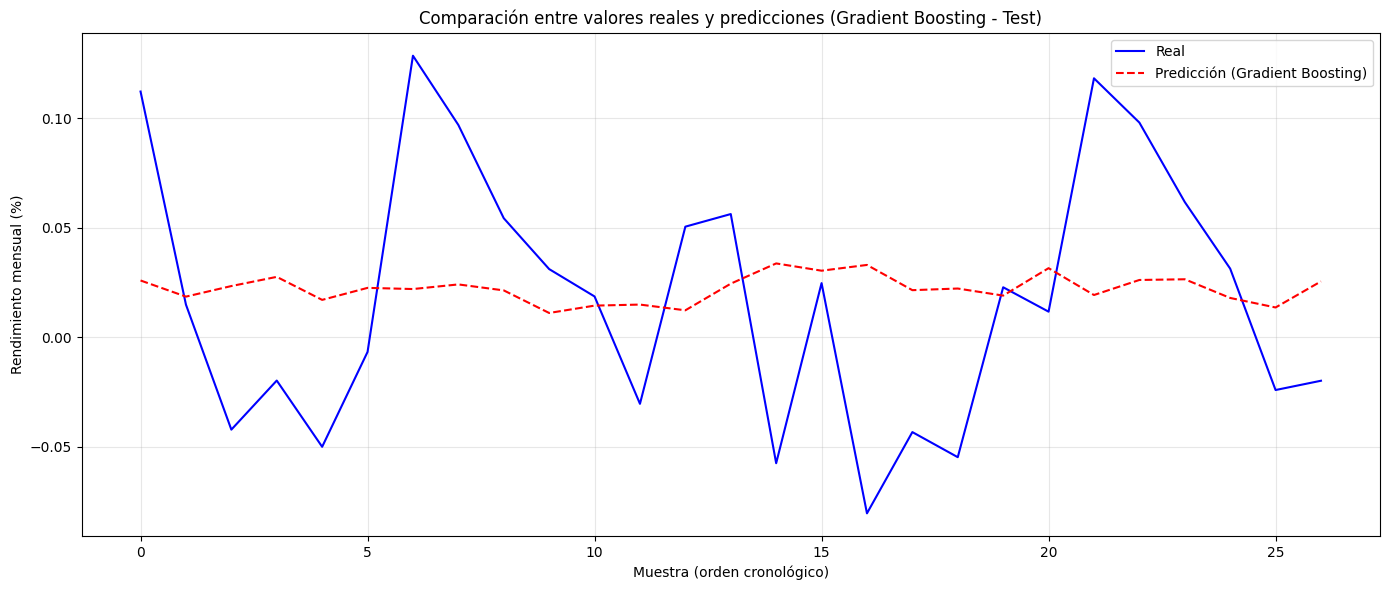

In [9]:
plt.figure(figsize=(14, 6))

# Ordenar por índice (asegurar orden cronológico)
indices = range(len(y_test))

plt.plot(indices, y_test.values, label='Real', color='blue', linewidth=1.5)
plt.plot(indices, y_pred_test, label='Predicción (Gradient Boosting)', color='red', linestyle='--', linewidth=1.5)

plt.title('Comparación entre valores reales y predicciones (Gradient Boosting - Test)')
plt.xlabel('Muestra (orden cronológico)')
plt.ylabel('Rendimiento mensual (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [10]:
def backtesting_gb(dataframe, window_train=200, test_size=24, step=12, best_params=None):
    """
    Realiza backtesting con ventana deslizante para Gradient Boosting.
    
    Parámetros:
    -----------
    dataframe : DataFrame
        Dataset completo ordenado cronológicamente
    window_train : int
        Tamaño de la ventana de entrenamiento (meses)
    test_size : int
        Tamaño de la ventana de prueba (meses)
    step : int
        Número de meses que se desplaza la ventana en cada iteración
    best_params : dict
        Mejores hiperparámetros encontrados en la búsqueda previa
        
    Retorna:
    --------
    resultados : DataFrame
        DataFrame con las métricas de cada iteración
    media_metricas : dict
        Diccionario con las métricas promedio
    """
    
    resultados = []  # Lista para almacenar los resultados de cada iteración
    
    # Si no se proporcionan mejores hiperparámetros, se usan valores por defecto
    if best_params is None:
        best_params = {
            'n_estimators': 200,
            'learning_rate': 0.01,
            'max_depth': 7,
            'subsample': 0.8,
            'min_samples_split': 2,
            'random_state': 42
        }
    
    # Calculamoa número total de iteraciones que se realizarán en el backtesting
    n_iterations = (len(dataframe) - window_train - test_size) // step + 1
    
    # Iteramos sobre el rango de índices para crear las ventanas de entrenamiento y prueba
    for i, start in enumerate(range(0, len(dataframe) - window_train - test_size, step)):
        
        # Definimos los límites de las ventanas
        train_end = start + window_train
        test_end = train_end + test_size
        
        # Obtenemos los datos de entrenamiento y prueba
        train = dataframe.iloc[start:train_end]
        test = dataframe.iloc[train_end:test_end]
        
        # Separamos características (X) y variable objetivo (y)
        X_train = train.drop(columns=['target'])
        y_train = train['target']
        
        X_test = test.drop(columns=['target'])
        y_test = test['target']
        
        # Creamos y entrenamos el modelo con los mejores hiperparámetros
        gb = GradientBoostingRegressor(**best_params)
        gb.fit(X_train, y_train)
        
        # Realizamos predicciones
        y_pred = gb.predict(X_test)
        
        # Calculamos métricas
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)
        
        # Información de las fechas (si el índice es numérico, mostrar rangos)
        if isinstance(dataframe.index, pd.RangeIndex):
            periodo_train = f"[{start}:{train_end-1}]"
            periodo_test = f"[{train_end}:{test_end-1}]"
        else: #Si el índice es de tipo fecha, mostrar los rangos de fechas
            periodo_train = f"{train.index[0]} - {train.index[-1]}"
            periodo_test = f"{test.index[0]} - {test.index[-1]}"
        
        # Guardar los resultados de cada iteración
        resultados.append({
            'iteracion': i + 1,
            'train_inicio': start,
            'train_fin': train_end - 1,
            'test_inicio': train_end,
            'test_fin': test_end - 1,
            'MAE': mae,
            'RMSE': rmse,
            'R2': r2
        })
        
    # Convertir la lista de resultados a un DataFrame
    df_resultados = pd.DataFrame(resultados)
    
    # Calcular métricas promedio y su desviación estándar
    media_metricas = {
        'MAE_mean': df_resultados['MAE'].mean(),
        'MAE_std': df_resultados['MAE'].std(),
        'RMSE_mean': df_resultados['RMSE'].mean(),
        'RMSE_std': df_resultados['RMSE'].std(),
        'R2_mean': df_resultados['R2'].mean(),
        'R2_std': df_resultados['R2'].std()
    }
    
    print(f"MAE medio: {media_metricas['MAE_mean']:.4f} (±{media_metricas['MAE_std']:.4f})")
    print(f"RMSE medio: {media_metricas['RMSE_mean']:.4f} (±{media_metricas['RMSE_std']:.4f})")
    print(f"R² medio: {media_metricas['R2_mean']:.4f} (±{media_metricas['R2_std']:.4f})")
    
    return df_resultados, media_metricas


In [11]:
best_params_gb = grid_search_gb.best_params_
best_params_gb['random_state'] = 42

# Ejecutamos backtesting
resultados_backtest, metricas_backtest = backtesting_gb(
    dataframe=df,
    window_train=200,  # 200 meses de entrenamiento (~16.7 años)
    test_size=24,      # 24 meses de prueba (~2 años)
    step=12,           # Desplazar la ventana 12 meses cada iteración
    best_params=best_params_gb
)

MAE medio: 0.0655 (±0.0108)
RMSE medio: 0.0778 (±0.0106)
R² medio: -0.0963 (±0.0383)


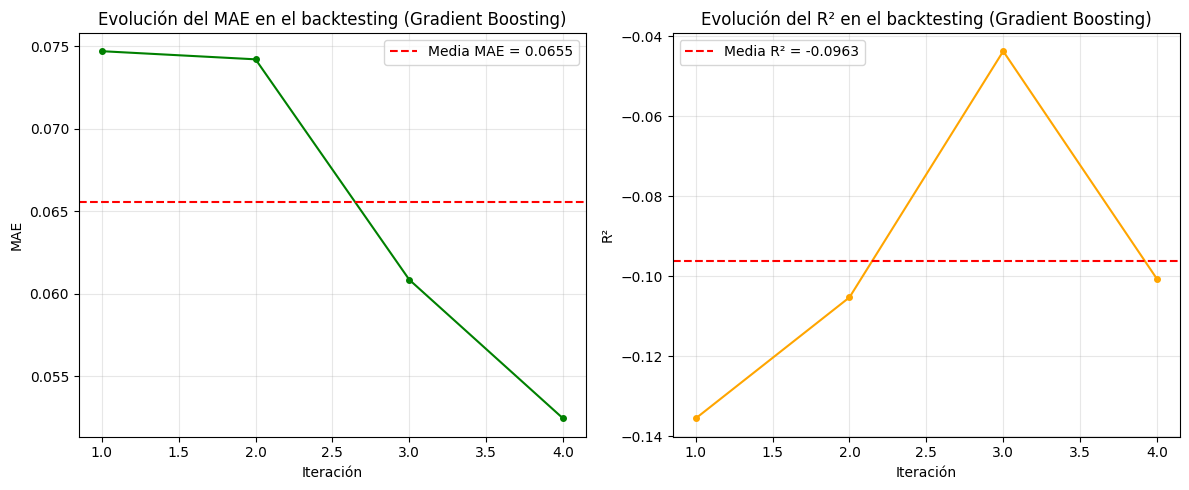

In [12]:
plt.figure(figsize=(12, 5))

# Subgráfica 1: Evolución del MAE en el backtesting
plt.subplot(1, 2, 1)
plt.plot(resultados_backtest['iteracion'], resultados_backtest['MAE'], 'o-', color='green', markersize=4)
plt.axhline(y=metricas_backtest['MAE_mean'], color='red', linestyle='--', label=f'Media MAE = {metricas_backtest["MAE_mean"]:.4f}')
plt.xlabel('Iteración')
plt.ylabel('MAE')
plt.title('Evolución del MAE en el backtesting (Gradient Boosting)')
plt.legend()
plt.grid(True, alpha=0.3)

# Subgráfica 2: Evolución del R² en el backtesting
plt.subplot(1, 2, 2)
plt.plot(resultados_backtest['iteracion'], resultados_backtest['R2'], 'o-', color='orange', markersize=4)
plt.axhline(y=metricas_backtest['R2_mean'], color='red', linestyle='--', label=f'Media R² = {metricas_backtest["R2_mean"]:.4f}')
plt.xlabel('Iteración')
plt.ylabel('R²')
plt.title('Evolución del R² en el backtesting (Gradient Boosting)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

=== GRADIENT BOOSTING - VALIDACIÓN ===
MAE: 0.0716
RMSE: 0.0834



In [13]:
joblib.dump(best_gb, 'gradient_boosting_model.pkl')

['gradient_boosting_model.pkl']